/tmp/ipykernel_356/1270894287.py:20: RuntimeWarning: invalid value encountered in scalar divide
  m = -W[1] / W[2]
/tmp/ipykernel_356/1270894287.py:21: RuntimeWarning: invalid value encountered in scalar divide
  b = -W[0] / W[2]


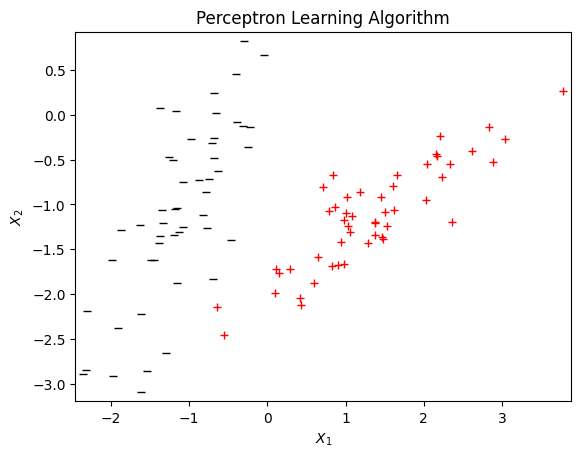

Errors: 100
Errors: 36
Errors: 1
Errors: 44
Errors: 5
Errors: 12
Errors: 2
Errors: 13
Errors: 4
Errors: 8
Errors: 2
Errors: 10
Errors: 2
Errors: 3
Errors: 0


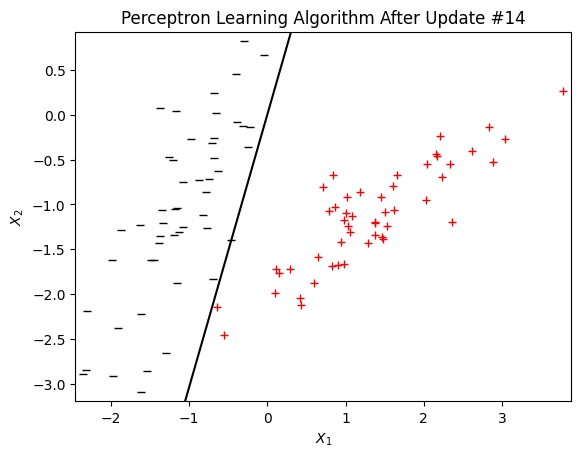

Final Weights : [ 0.          6.65350309 -2.18783187]
Total Iterations : 14


In [ ]:
#week 4 perceptron learning algorithm
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


def pltPer(X, y, W, it=-1):
    title = "Perceptron Learning Algorithm"
    if it > 0:
        title = title + " After Update #" + str(it)

    plt.figure()

    for n in range(len(y)):
        if y[n] == 1:
            plt.plot(X[n,1], X[n,2], 'r+')
        else:
            plt.plot(X[n,1], X[n,2], 'k_')

    m = -W[1] / W[2]
    b = -W[0] / W[2]

    l = np.linspace(min(X[:,1]), max(X[:,1]))
    plt.plot(l, m*l + b, 'k-')

    plt.axis('tight')
    plt.xlim(min(X[:,1])-0.1, max(X[:,1])+0.1)
    plt.ylim(min(X[:,2])-0.1, max(X[:,2])+0.1)

    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.title(title)
    plt.show()


def classification_error(w, X, y):
    err_cnt = 0
    N = len(X)

    for n in range(N):
        s = np.sign(w.T.dot(X[n]))
        if y[n] != s:
            err_cnt += 1

    print("Errors:", err_cnt)
    return err_cnt


def choose_miscl_point(w, X, y):
    mispts = []

    for n in range(len(X)):
        if np.sign(w.T.dot(X[n])) != y[n]:
            mispts.append((X[n], y[n]))

    return mispts[random.randrange(0, len(mispts))]


N = 100

random.seed(7)
np.random.seed(7)

X, y = make_classification(
    n_samples=N,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=5
)

# Convert labels from 0,1 to -1,+1
y[y == 0] = -1

# Add bias column
X_train = np.append(np.ones((N,1)), X, axis=1)

# Initialize weights
w = np.zeros(X_train.shape[1])

it = 0
pltPer(X_train, y, w)

while classification_error(w, X_train, y) != 0:

    it += 1

    x, s = choose_miscl_point(w, X_train, y)

    # Weight Update Rule
    w += s * x

    if it > 1000:
        break

pltPer(X_train, y, w, it)

print("Final Weights :", w)
print("Total Iterations :", it)